In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

from sklearn.preprocessing import OneHotEncoder, StandardScaler, StandardScaler
#from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

#from yellowbrick.cluster import KElbowVisualizer

In [ ]:
# pip install threadpoolctl==3.1.0

In [2]:
#import warnings
#warnings.filterwarnings("ignore")

In [3]:
pwd

'\\\\wsl.localhost\\Ubuntu\\home\\dgaillot\\code\\openclassrooms\\openclassrooms\\projets\\projet_5'

In [4]:
#df = pd.read_csv('data/olist_rfm.csv')

df = pd.read_csv('data/clean_df_customers.csv')

In [5]:
df.head()

,customer_unique_id,recency,frequency,monetary,main_category,mean_review_score,ratio_comment_message,ratio_credit_card,mean_pay_installments,mean_pay_sequential,region
0,7c396fd4830fd04220f754e42b4e5bff,380,2,65.38,health_beauty,4,100.0,50.0,1.0,1.75,SE
1,af07308b275d755c9edb36a90c618231,85,1,118.70,health_beauty,4,100.0,0.0,1.0,1.00,NE
2,3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.90,auto,5,0.0,100.0,3.0,1.00,CW
3,7c142cf63193a1473d2e66489a9ae977,333,1,45.00,misc,3,100.0,100.0,1.0,1.00,NE
4,72632f0f9dd73dfee390c9b22eb56dd6,246,1,19.90,books_stationery,4,0.0,100.0,1.0,1.00,SE


In [6]:
# remove customer_unique_id
df.drop(['customer_unique_id'], axis=1, inplace=True)
df.head()

,recency,frequency,monetary,main_category,mean_review_score,ratio_comment_message,ratio_credit_card,mean_pay_installments,mean_pay_sequential,region
0,380,2,65.38,health_beauty,4,100.0,50.0,1.0,1.75,SE
1,85,1,118.70,health_beauty,4,100.0,0.0,1.0,1.00,NE
2,70,1,159.90,auto,5,0.0,100.0,3.0,1.00,CW
3,333,1,45.00,misc,3,100.0,100.0,1.0,1.00,NE
4,246,1,19.90,books_stationery,4,0.0,100.0,1.0,1.00,SE


In [7]:
df.head()

,recency,frequency,monetary,main_category,mean_review_score,ratio_comment_message,ratio_credit_card,mean_pay_installments,mean_pay_sequential,region
0,380,2,65.38,health_beauty,4,100.0,50.0,1.0,1.75,SE
1,85,1,118.70,health_beauty,4,100.0,0.0,1.0,1.00,NE
2,70,1,159.90,auto,5,0.0,100.0,3.0,1.00,CW
3,333,1,45.00,misc,3,100.0,100.0,1.0,1.00,NE
4,246,1,19.90,books_stationery,4,0.0,100.0,1.0,1.00,SE


In [8]:
df.shape

(95443, 10)

In [9]:
df.dtypes

recency                    int64
frequency                  int64
monetary                 float64
main_category             object
mean_review_score          int64
ratio_comment_message    float64
ratio_credit_card        float64
mean_pay_installments    float64
mean_pay_sequential      float64
region                    object
dtype: object

In [10]:
df.isna().sum()

recency                  0
frequency                0
monetary                 0
main_category            0
mean_review_score        0
ratio_comment_message    0
ratio_credit_card        0
mean_pay_installments    0
mean_pay_sequential      0
region                   0
dtype: int64

In [11]:
quantiles = df.quantile(q=[0.25,0.5,0.75])
quantiles

,recency,frequency,monetary,mean_review_score,ratio_comment_message,ratio_credit_card,mean_pay_installments,mean_pay_sequential
0.25,163.0,1.0,47.9,4.0,0.0,50.0,1.0,1.0
0.50,268.0,1.0,89.9,5.0,0.0,100.0,2.0,1.0
0.75,397.0,1.0,155.0,5.0,100.0,100.0,4.0,1.0


# Distribution

<AxesSubplot:xlabel='monetary', ylabel='Count'>

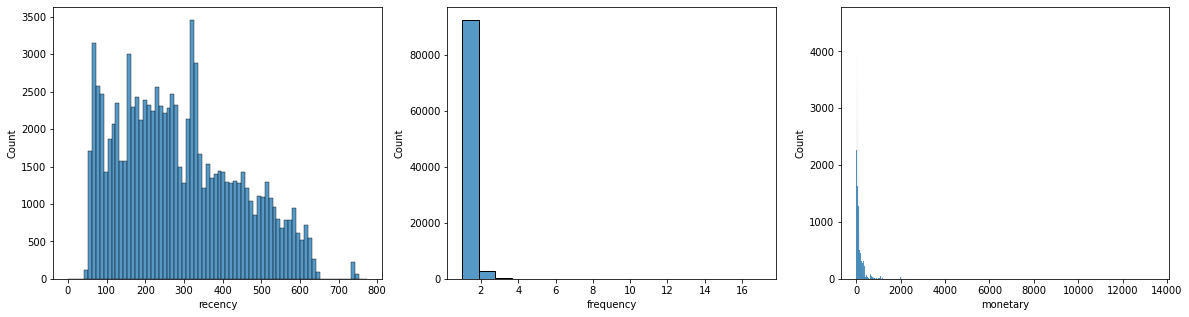

In [12]:
#Plot data distribution
plt.figure(figsize=(20,5))

plt.subplot(1,3,1)
sns.histplot(df['recency'])

plt.subplot(1,3,2)
sns.histplot(df['frequency'])

plt.subplot(1,3,3)
sns.histplot(df['monetary'])

In [13]:
#apply log transformation 
rfm_log = df[['recency', 'frequency', 'monetary']].apply(np.log, axis=1).round(3)

In [14]:
rfm_log.head()

,recency,frequency,monetary
0,5.940,0.693,4.180
1,4.443,0.000,4.777
2,4.248,0.000,5.075
3,5.808,0.000,3.807
4,5.505,0.000,2.991


<AxesSubplot:xlabel='monetary', ylabel='Count'>

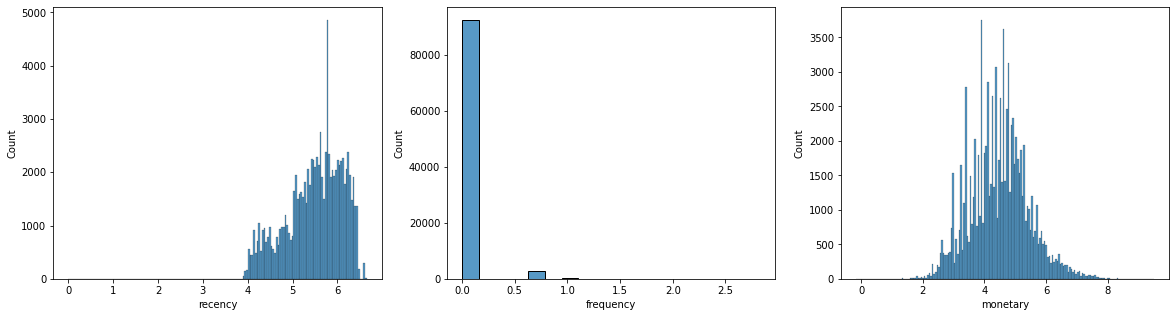

In [15]:
#Plot data distribution after log transformation
plt.figure(figsize=(20,5))

plt.subplot(1,3,1)
sns.histplot(rfm_log['recency'])

plt.subplot(1,3,2)
sns.histplot(rfm_log['frequency'])

plt.subplot(1,3,3)
sns.histplot(rfm_log['monetary'])

In [16]:
num_cols = df.select_dtypes(include=np.number).columns.to_list()
num_cols

['recency',
 'frequency',
 'monetary',
 'mean_review_score',
 'ratio_comment_message',
 'ratio_credit_card',
 'mean_pay_installments',
 'mean_pay_sequential']

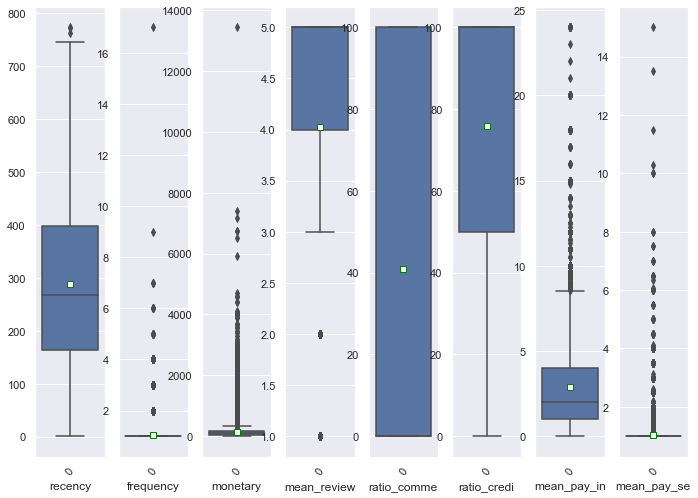

In [17]:
MVA.boxplot_nums(df, num_cols)

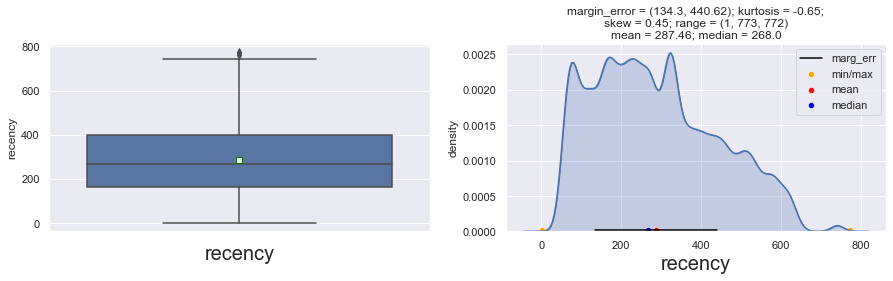

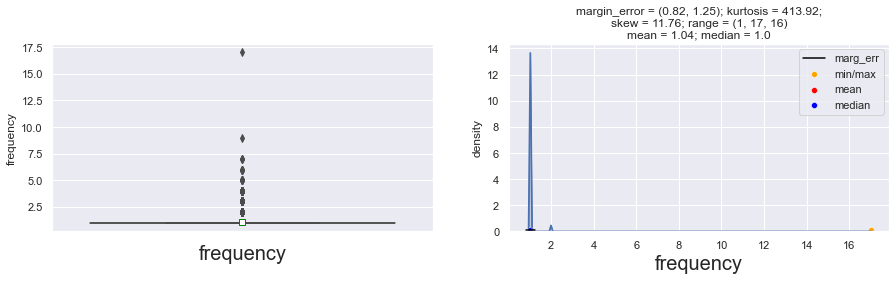

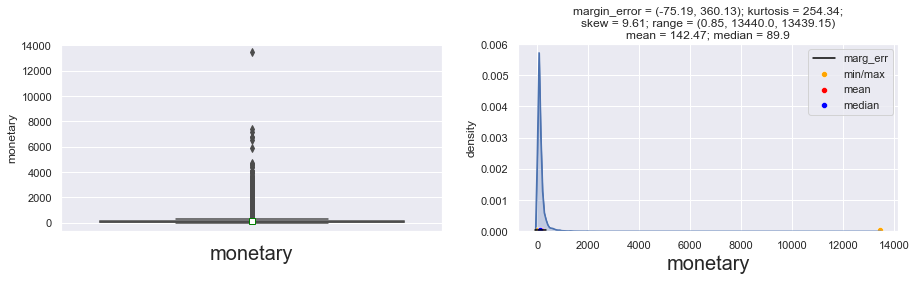

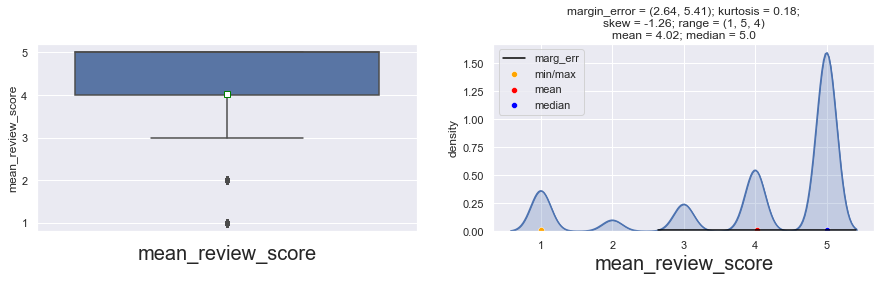

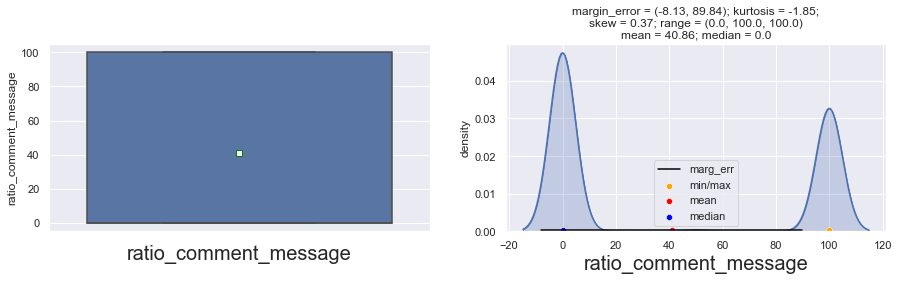

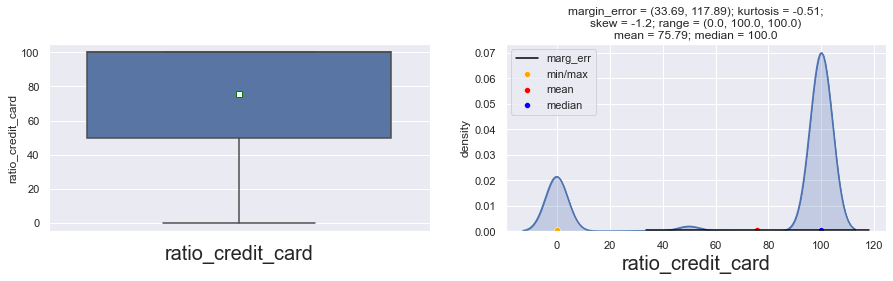

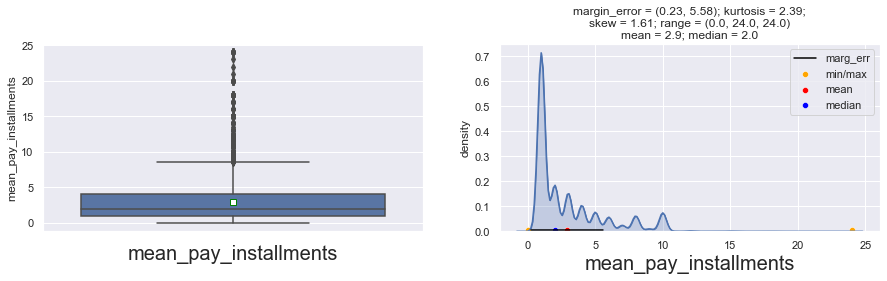

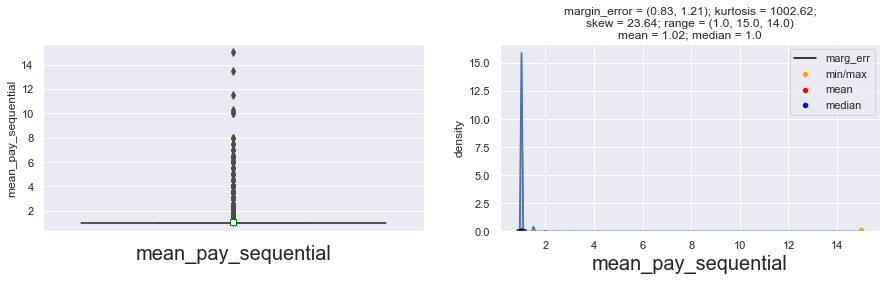

In [18]:
UVA.num_plus(df, num_cols)

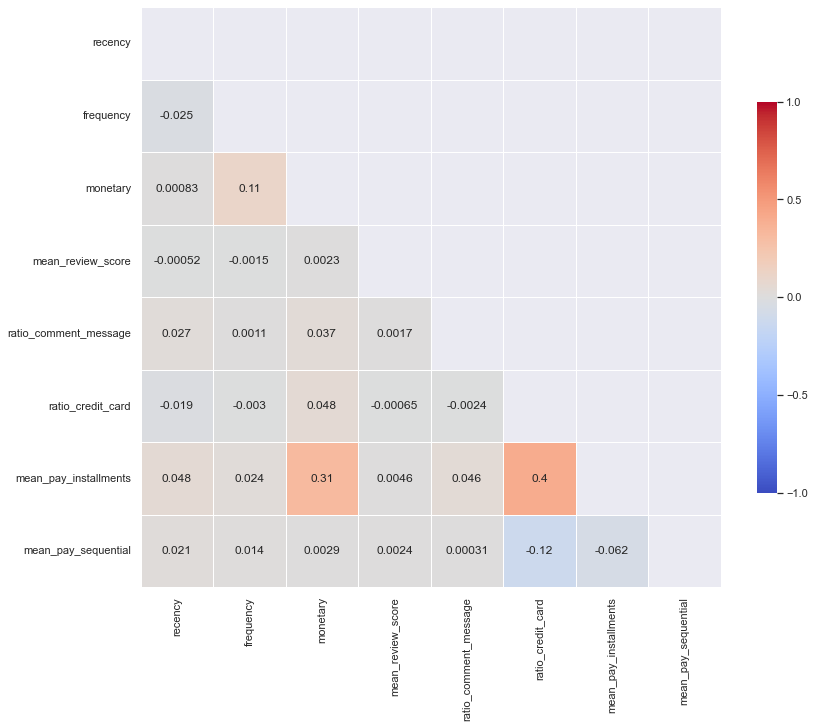

In [59]:
MVA.heatmap_num_2(df)

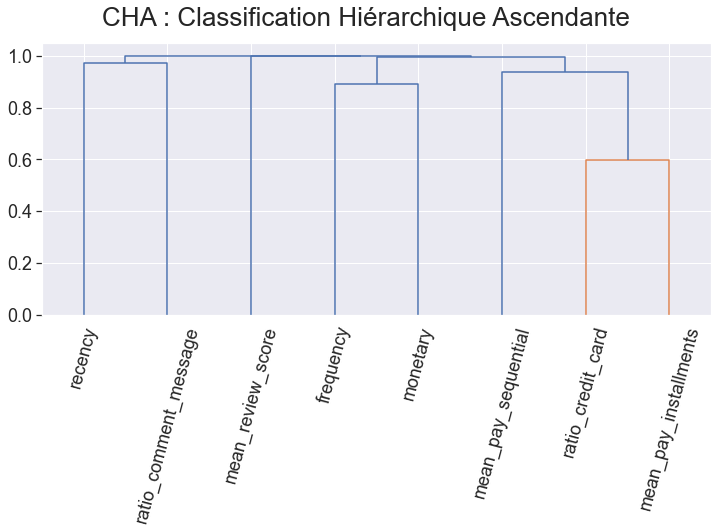

In [60]:
PCA.CHA(df, num_cols)

# Echantillon

In [19]:
df_redux = df.sample(10000, random_state=1).copy()
X = df_redux.copy()
#categorical_columns = X.select_dtypes(['category','object']).columns
num_cols = X.select_dtypes(include=np.number).columns.to_list()

ss = StandardScaler()
X[num_cols] = ss.fit_transform(X[num_cols])

In [20]:
X

,recency,frequency,monetary,main_category,mean_review_score,ratio_comment_message,ratio_credit_card,mean_pay_installments,mean_pay_sequential,region
84370,0.251341,-0.177371,-0.403517,health_beauty,0.700864,-0.834219,-1.811999,-0.713223,-0.132899,S
53628,-0.757210,-0.177371,6.907260,sports_leisure,-0.014741,1.207629,0.571456,1.517691,-0.132899,SE
83291,-0.514896,-0.177371,-0.197641,furniture,-0.014741,-0.834219,0.571456,-0.341404,-0.132899,SE
2015,-0.979877,-0.177371,-0.423275,home,0.700864,1.207629,0.571456,0.774053,-0.132899,S
77038,-0.049915,-0.177371,0.999681,auto,0.700864,-0.834219,0.571456,-0.713223,-0.132899,SE
...,...,...,...,...,...,...,...,...,...,...
9143,-0.580386,9.462358,1.025919,unknown,0.700864,1.207629,-1.017514,-0.713223,2.503543,SE
3876,-1.385916,-0.177371,-0.420509,home,-2.161559,1.207629,0.571456,-0.713223,-0.132899,SE
50206,1.279538,-0.177371,7.341892,auto,0.700864,1.207629,0.571456,2.633148,-0.132899,SE
10926,-0.049915,-0.177371,-0.347840,health_beauty,0.700864,1.207629,-1.811999,-0.713223,-0.132899,SE


### encoding categories

In [21]:
X = X.reset_index().drop(columns='index')

In [22]:
cat_cols = df.select_dtypes(['category','object']).columns
df[cat_cols].describe()

,main_category,region
count,95443,95443
unique,13,5
top,furniture,SE
freq,16890,65410


In [23]:
X[cat_cols].head()

,main_category,region
0,health_beauty,S
1,sports_leisure,SE
2,furniture,SE
3,home,S
4,auto,SE


In [24]:
ohe = OneHotEncoder(sparse_output=False)

In [25]:
multiple_ohe = ohe.fit_transform(X[cat_cols])

In [26]:
ohe_df = pd.DataFrame(multiple_ohe, columns=ohe.get_feature_names_out())

In [27]:
ohe_df.columns

Index(['main_category_auto', 'main_category_books_stationery',
       'main_category_construction', 'main_category_electronics',
       'main_category_fashion', 'main_category_furniture',
       'main_category_garden', 'main_category_health_beauty',
       'main_category_home', 'main_category_misc',
       'main_category_sports_leisure', 'main_category_toys_gifts',
       'main_category_unknown', 'region_CW', 'region_N', 'region_NE',
       'region_S', 'region_SE'],
      dtype='object')

In [29]:
# merge features
X_num = X.drop(columns=cat_cols)
X_enc = pd.concat([ohe_df, X_num],axis=1)
X_enc

,main_category_auto,main_category_books_stationery,main_category_construction,main_category_electronics,main_category_fashion,main_category_furniture,main_category_garden,main_category_health_beauty,main_category_home,main_category_misc,...,region_S,region_SE,recency,frequency,monetary,mean_review_score,ratio_comment_message,ratio_credit_card,mean_pay_installments,mean_pay_sequential
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.251341,-0.177371,-0.403517,0.700864,-0.834219,-1.811999,-0.713223,-0.132899
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-0.757210,-0.177371,6.907260,-0.014741,1.207629,0.571456,1.517691,-0.132899
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-0.514896,-0.177371,-0.197641,-0.014741,-0.834219,0.571456,-0.341404,-0.132899
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,-0.979877,-0.177371,-0.423275,0.700864,1.207629,0.571456,0.774053,-0.132899
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-0.049915,-0.177371,0.999681,0.700864,-0.834219,0.571456,-0.713223,-0.132899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-0.580386,9.462358,1.025919,0.700864,1.207629,-1.017514,-0.713223,2.503543
9996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,-1.385916,-0.177371,-0.420509,-2.161559,1.207629,0.571456,-0.713223,-0.132899
9997,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.279538,-0.177371,7.341892,0.700864,1.207629,0.571456,2.633148,-0.132899
9998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,-0.049915,-0.177371,-0.347840,0.700864,1.207629,-1.811999,-0.713223,-0.132899


In [30]:
X_enc.dtypes

main_category_auto                float64
main_category_books_stationery    float64
main_category_construction        float64
main_category_electronics         float64
main_category_fashion             float64
main_category_furniture           float64
main_category_garden              float64
main_category_health_beauty       float64
main_category_home                float64
main_category_misc                float64
main_category_sports_leisure      float64
main_category_toys_gifts          float64
main_category_unknown             float64
region_CW                         float64
region_N                          float64
region_NE                         float64
region_S                          float64
region_SE                         float64
recency                           float64
frequency                         float64
monetary                          float64
mean_review_score                 float64
ratio_comment_message             float64
ratio_credit_card                 

In [31]:
X_enc.isna().sum()

main_category_auto                0
main_category_books_stationery    0
main_category_construction        0
main_category_electronics         0
main_category_fashion             0
main_category_furniture           0
main_category_garden              0
main_category_health_beauty       0
main_category_home                0
main_category_misc                0
main_category_sports_leisure      0
main_category_toys_gifts          0
main_category_unknown             0
region_CW                         0
region_N                          0
region_NE                         0
region_S                          0
region_SE                         0
recency                           0
frequency                         0
monetary                          0
mean_review_score                 0
ratio_comment_message             0
ratio_credit_card                 0
mean_pay_installments             0
mean_pay_sequential               0
dtype: int64

### X_std / echantillon

In [32]:
X_std = PCA.clean_data(df, num_cols, impute=False, std=True)

	>>> Selected features: ['recency', 'frequency', 'monetary', 'mean_review_score', 'ratio_comment_message', 'ratio_credit_card', 'mean_pay_installments', 'mean_pay_sequential']
	>>> Standardized data


In [33]:
X_std

,recency,frequency,monetary,mean_review_score,ratio_comment_message,ratio_credit_card,mean_pay_installments,mean_pay_sequential
0,0.604196,4.471253,-0.354187,-0.017754,1.207342,-0.612509,-0.710736,3.810427
1,-1.321872,-0.163352,-0.109218,-0.017754,1.207342,-1.800079,-0.710736,-0.120893
2,-1.419808,-0.163352,0.080068,0.702083,-0.834115,0.575061,0.036153,-0.120893
3,0.297331,-0.163352,-0.447819,-0.737591,1.207342,0.575061,-0.710736,-0.120893
4,-0.270696,-0.163352,-0.563137,-0.017754,-0.834115,0.575061,-0.710736,-0.120893
...,...,...,...,...,...,...,...,...
95438,1.955708,-0.163352,-0.323773,0.702083,-0.834115,0.575061,0.036153,-0.120893
95439,-0.224993,-0.163352,0.148983,0.702083,1.207342,0.575061,0.036153,-0.120893
95440,0.839242,-0.163352,0.291820,0.702083,1.207342,0.575061,0.783043,-0.120893
95441,-0.035650,-0.163352,0.999299,-2.177266,1.207342,0.575061,0.409598,-0.120893


# PCA

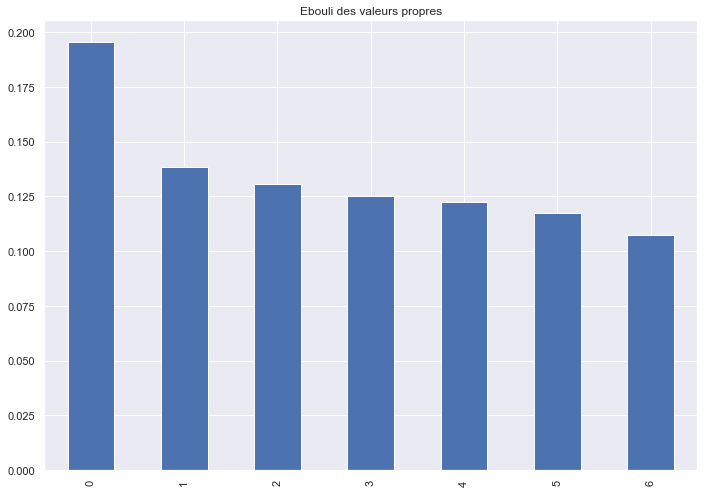

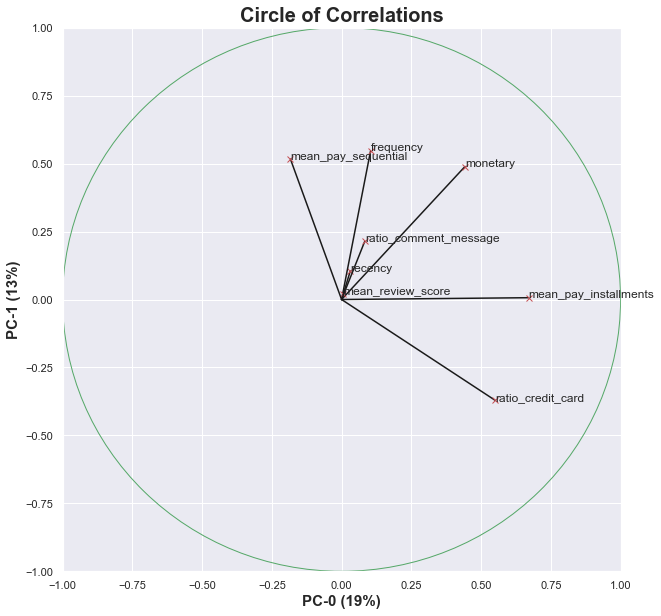

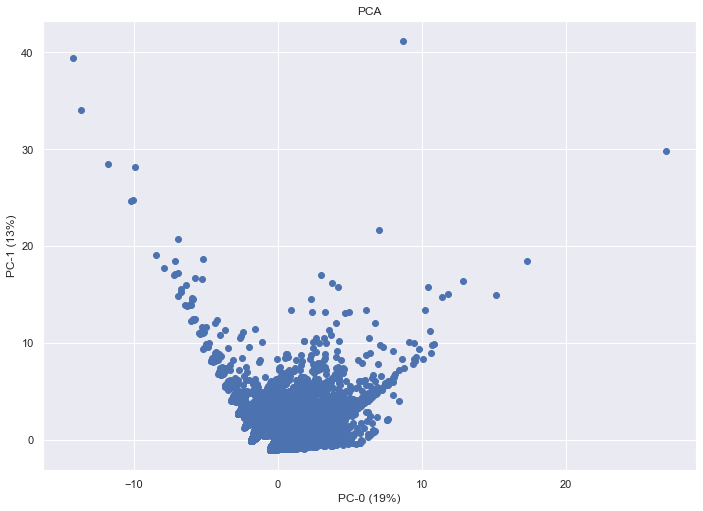

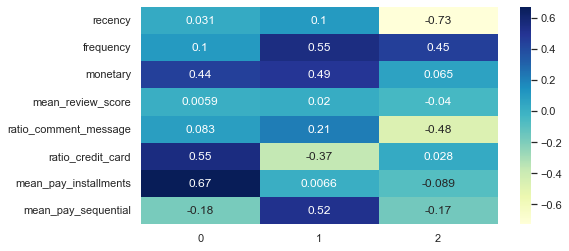

Résumé PCA
Total: 7 composants
----------------------------------------
Moyenne de la variance expliquée : 0.134
----------------------------------------
   explained variance  cumulative
1            0.195599    0.195599
2            0.138331    0.333929
3            0.130515    0.464444
4            0.125010    0.589454
5            0.122373    0.711827
6            0.117205    0.829032
7            0.107549    0.936580
----------------------------------------


,PC-0,PC-1,PC-2,PC-3,PC-4,PC-5,PC-6
recency,0.031233,0.104803,-0.727705,0.062749,0.396426,-0.536383,-0.051388
frequency,0.103863,0.546545,0.448847,0.025633,-0.089665,-0.523387,-0.451917
monetary,0.442326,0.489303,0.065098,0.002913,0.047965,0.073015,0.622075
mean_review_score,0.005876,0.020064,-0.040089,-0.997421,0.002156,-0.054838,-0.008228
ratio_comment_message,0.083245,0.214411,-0.475497,0.017975,-0.828823,0.101182,-0.149179
ratio_credit_card,0.550432,-0.370943,0.028358,-0.003989,0.066278,0.103031,-0.484079
mean_pay_installments,0.670109,0.006615,-0.088581,-0.002902,0.110488,0.132389,-0.027447
mean_pay_sequential,-0.183299,0.516595,-0.168489,-0.014157,0.359100,0.625812,-0.385675


In [34]:
PCA.myPCA(X_std)

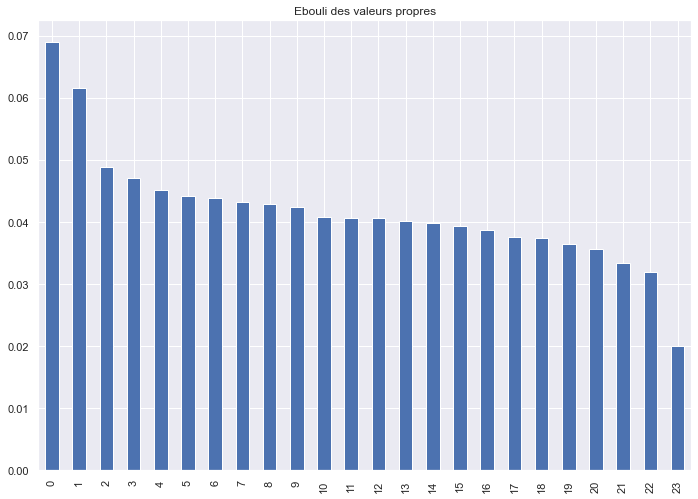

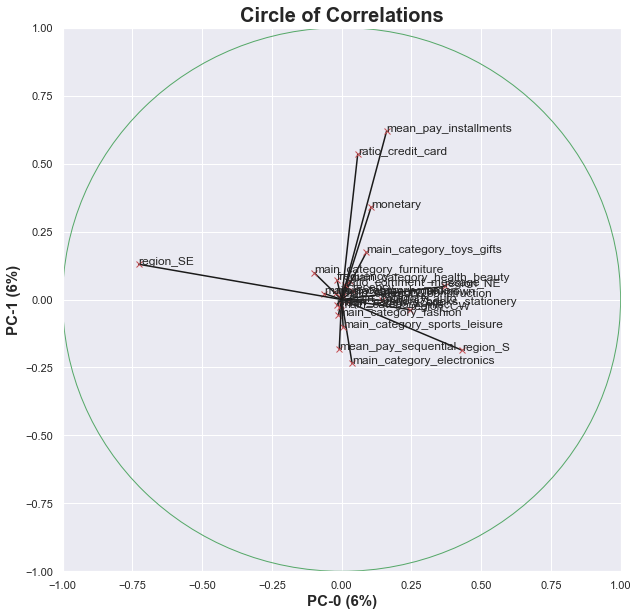

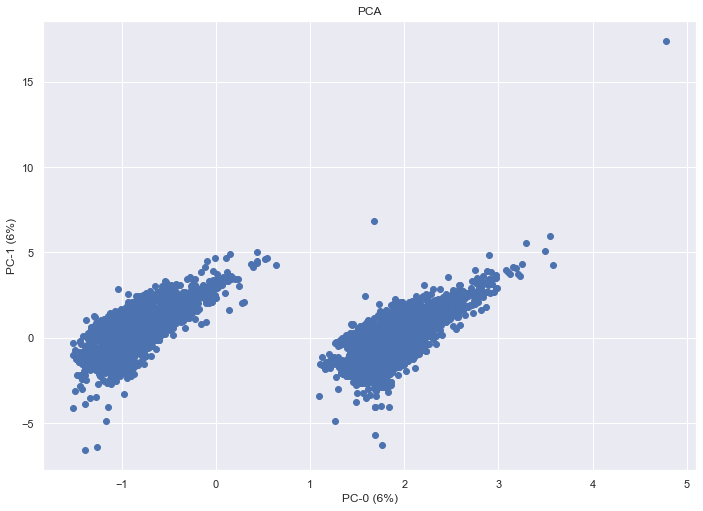

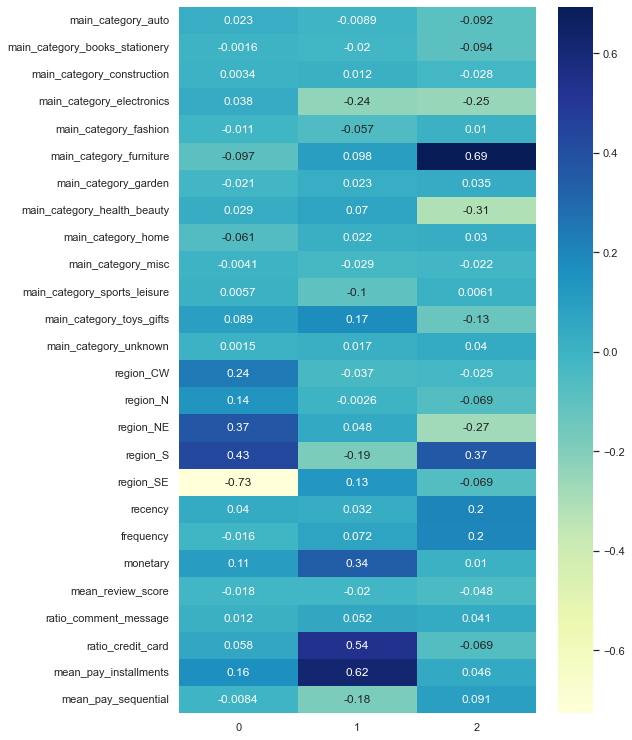

Résumé PCA
Total: 24 composants
----------------------------------------
Moyenne de la variance expliquée : 0.042
----------------------------------------
    explained variance  cumulative
1             0.068997    0.068997
2             0.061489    0.130486
3             0.048804    0.179290
4             0.047058    0.226348
5             0.045107    0.271455
6             0.044168    0.315623
7             0.043770    0.359393
8             0.043192    0.402585
9             0.042891    0.445476
10            0.042408    0.487884
11            0.040809    0.528693
12            0.040650    0.569343
13            0.040547    0.609890
14            0.040144    0.650034
15            0.039760    0.689794
16            0.039343    0.729137
17            0.038650    0.767787
18            0.037492    0.805279
19            0.037386    0.842665
20            0.036487    0.879152
----------------------------------------


,PC-0,PC-1,PC-2,PC-3,PC-4,PC-5,PC-6,PC-7,PC-8,PC-9,...,PC-14,PC-15,PC-16,PC-17,PC-18,PC-19,PC-20,PC-21,PC-22,PC-23
main_category_auto,0.022533,-0.008922,-0.091786,-0.069407,0.033733,0.018202,0.306421,-0.094650,-0.032517,-0.209322,...,-0.476025,-0.141081,-0.228674,0.030250,0.030503,0.200103,0.036618,0.087010,-0.204074,-0.006491
main_category_books_stationery,-0.001585,-0.019802,-0.094392,-0.127570,-0.177588,0.000074,-0.237492,-0.042244,-0.181663,-0.292455,...,0.457665,-0.183772,0.356206,0.032504,0.279512,-0.120891,0.292584,0.106663,-0.058864,-0.012271
main_category_construction,0.003391,0.012065,-0.027593,-0.307773,-0.126499,0.050437,0.298341,-0.084701,-0.201062,0.064836,...,0.208603,0.443162,0.043733,0.255747,-0.383344,-0.216196,-0.047247,0.261214,-0.310275,0.033413
main_category_electronics,0.037716,-0.235364,-0.254466,0.272329,-0.231979,0.658439,0.054102,-0.133391,0.057785,0.254803,...,-0.001323,0.010732,-0.004529,-0.085229,0.073147,0.074522,0.096729,-0.118657,-0.113450,-0.062559
main_category_fashion,-0.011232,-0.057353,0.010324,0.063032,0.007492,-0.094838,-0.167510,0.056512,0.079431,-0.075572,...,-0.023426,0.706957,0.023754,-0.232483,-0.009335,0.102236,0.196595,-0.051260,0.175525,-0.017486
main_category_furniture,-0.097405,0.097603,0.694216,0.075480,0.253788,0.252239,-0.044406,-0.135044,-0.201869,-0.166194,...,0.048470,-0.022272,-0.079356,0.087993,-0.087156,0.028883,-0.147718,-0.003697,0.178791,0.078921
main_category_garden,-0.021424,0.023358,0.034986,0.102037,-0.020598,-0.061482,-0.017394,0.104829,0.219121,0.031801,...,0.407612,-0.111213,-0.030664,-0.012119,-0.067816,0.128830,-0.182011,-0.097228,0.100297,-0.003926
main_category_health_beauty,0.029221,0.069877,-0.312457,-0.329952,0.598113,0.006859,-0.278641,0.297235,-0.056366,0.217269,...,-0.045208,-0.012470,-0.156213,-0.036911,0.096078,-0.094460,0.056926,0.049805,-0.042721,0.025989
main_category_home,-0.061426,0.021925,0.029927,-0.185228,-0.270541,-0.061589,0.215092,0.472876,0.243805,-0.082549,...,-0.103061,-0.173797,0.144229,-0.034819,-0.244426,-0.065422,-0.024787,0.107054,0.040769,0.022975
main_category_misc,-0.004096,-0.029061,-0.021607,-0.045860,-0.070507,-0.047371,-0.003440,0.075659,0.046332,-0.297776,...,-0.144676,-0.265325,0.175695,-0.109674,-0.147030,-0.053648,0.053890,-0.025135,0.005150,-0.001596


In [35]:
PCA.myPCA(X_enc)

# K-Means

In [ ]:
# print avancement au fur et à mesure

In [ ]:
# pip install threadpoolctl==3.1.0

### Elbow method

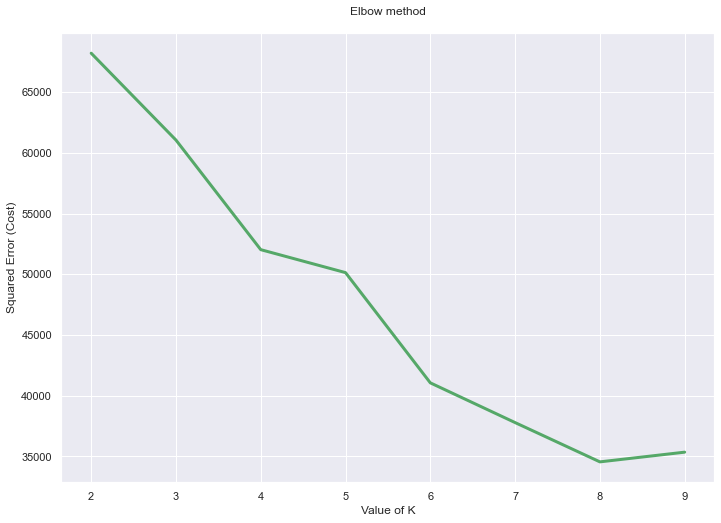

In [52]:
cost =[]
test_clusters = [i for i in range(2, 10)]
for i in test_clusters:
    #cls=KMeans(n_clusters=i,n_init=50,init='k-means++')
    cls = KMeans(n_clusters=i)
    cls.fit(X_num)
    cost.append(cls.inertia_)    


plt.plot(test_clusters, cost, color ='g', linewidth ='3')
plt.title("Elbow method\n")
plt.xlabel("Value of K")
plt.ylabel("Squared Error (Cost)")
#plt.axvline(x=nb_groupes_de_points, ymin=0, ymax=1, color="red")
plt.show()

In [34]:
# recherche nb optimum de clusters
## inertia = Sum of squared distances of samples to their closest cluster center

In [50]:
inertia = {}
dict_kmeans = {}
for k in range(1,25):
    print(k)
    kmeans = KMeans(n_clusters=k,
                   verbose=1,
                   random_state=0
                   ).fit(X_std)
    inertia[k] = kmeans.inertia_
    dict_kmeans[k] = kmeans

1
Initialization complete
Iteration 0, inertia 1697323.2974817224.
Iteration 1, inertia 763544.0000000002.
Converged at iteration 1: strict convergence.
2
Initialization complete
Iteration 0, inertia 907724.3732760804.
Iteration 1, inertia 687890.4611185663.
Iteration 2, inertia 667092.9055121506.
Iteration 3, inertia 656671.0592954652.
Iteration 4, inertia 651892.5726001324.
Converged at iteration 4: center shift 3.9486590691303224e-05 within tolerance 0.0001000000000000229.
3
Initialization complete
Iteration 0, inertia 790576.4684664409.
Iteration 1, inertia 623694.9924201163.
Iteration 2, inertia 612516.6552101189.
Iteration 3, inertia 593414.6322958106.
Iteration 4, inertia 582474.3459132704.
Iteration 5, inertia 581387.9116706795.
Iteration 6, inertia 581108.2332839846.
Iteration 7, inertia 581012.0608098023.
Iteration 8, inertia 580965.6770299356.
Iteration 9, inertia 580950.9843353882.
Iteration 10, inertia 580945.6384309693.
Converged at iteration 10: center shift 7.0614987561

Iteration 5, inertia 262054.82467416668.
Iteration 6, inertia 261772.58626110252.
Iteration 7, inertia 261656.10276441724.
Iteration 8, inertia 261599.6607303641.
Iteration 9, inertia 261579.75018092754.
Iteration 10, inertia 261573.9242502578.
Iteration 11, inertia 261570.6736553925.
Iteration 12, inertia 261569.32214373443.
Converged at iteration 12: center shift 5.605991558639584e-05 within tolerance 0.0001000000000000229.
13
Initialization complete
Iteration 0, inertia 321541.922756601.
Iteration 1, inertia 265441.76151497726.
Iteration 2, inertia 257495.44663426766.
Iteration 3, inertia 254610.13818551536.
Iteration 4, inertia 254218.8030432892.
Iteration 5, inertia 254137.73136551812.
Iteration 6, inertia 254105.2429845717.
Iteration 7, inertia 254091.95920974913.
Iteration 8, inertia 254086.1544845592.
Iteration 9, inertia 254082.5367423716.
Iteration 10, inertia 254079.94333771846.
Iteration 11, inertia 254077.28742897647.
Iteration 12, inertia 254075.3646928368.
Iteration 13, 

Initialization complete
Iteration 0, inertia 234394.33227954363.
Iteration 1, inertia 197559.77760825853.
Iteration 2, inertia 192838.25636712555.
Iteration 3, inertia 191301.23906062666.
Iteration 4, inertia 190241.360578277.
Iteration 5, inertia 189312.12110489968.
Iteration 6, inertia 188557.83604492893.
Iteration 7, inertia 188152.24513024482.
Iteration 8, inertia 187857.72953346648.
Iteration 9, inertia 187677.01722467146.
Iteration 10, inertia 187596.98311235127.
Iteration 11, inertia 187559.0211655454.
Iteration 12, inertia 187541.6650413421.
Iteration 13, inertia 187532.65819399775.
Iteration 14, inertia 187525.26187528134.
Iteration 15, inertia 187518.82007875296.
Iteration 16, inertia 187512.8186621829.
Iteration 17, inertia 187507.17621336295.
Iteration 18, inertia 187501.5418272898.
Iteration 19, inertia 187494.4760266342.
Iteration 20, inertia 187487.02099255892.
Iteration 21, inertia 187481.49679116358.
Iteration 22, inertia 187476.47420326088.
Iteration 23, inertia 18746

<AxesSubplot:title={'center':'Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters'}>

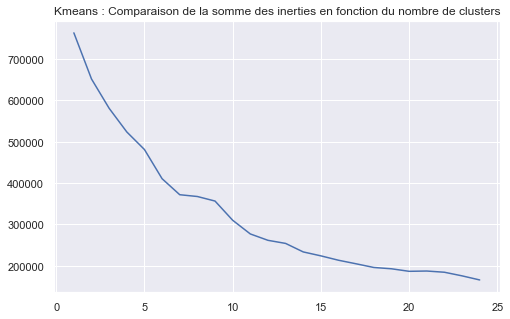

In [51]:
plt.figure(figsize=(8,5))
plt.title('Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters')
sns.lineplot(list(inertia.keys()),
             list(inertia.values())
            )


In [45]:
inertia = {}
dict_kmeans = {}

nb_boucles=3
max_clusters = 25

for k in range(1,nb_boucles+1):
    print('Boucle ',k)
    for i in range(1,max_clusters+1):
        kmeans = KMeans(n_clusters=i,
                       verbose=1,
                       #n_jobs=-1
                       ).fit(X_enc)
        inertia[(k,i)] = kmeans.inertia_
        dict_kmeans[k,i] = kmeans

Boucle  1
Initialization complete
Iteration 0, inertia 128978.4465063285.
Iteration 1, inertia 93900.02940000006.
Converged at iteration 1: strict convergence.
Initialization complete
Iteration 0, inertia 132025.414075629.
Iteration 1, inertia 86646.41186335408.
Iteration 2, inertia 85749.06650056654.
Iteration 3, inertia 84450.24982528077.
Iteration 4, inertia 83936.30660723482.
Iteration 5, inertia 83909.32019667786.
Iteration 6, inertia 83907.4668756899.
Converged at iteration 6: center shift 1.8862344337910483e-05 within tolerance 3.611539592307737e-05.
Initialization complete
Iteration 0, inertia 98234.8083977419.
Iteration 1, inertia 75621.97836442359.
Iteration 2, inertia 74947.83314509351.
Iteration 3, inertia 74943.58769748535.
Converged at iteration 3: strict convergence.
Initialization complete
Iteration 0, inertia 104837.94851096247.
Iteration 1, inertia 71893.5197421954.
Iteration 2, inertia 69998.31424629409.
Iteration 3, inertia 68611.46223988912.
Iteration 4, inertia 67

Iteration 16, inertia 38317.57784246378.
Converged at iteration 16: center shift 9.592504445645536e-06 within tolerance 3.611539592307737e-05.
Initialization complete
Iteration 0, inertia 56416.276441783484.
Iteration 1, inertia 37600.68828785035.
Iteration 2, inertia 36223.92136855389.
Iteration 3, inertia 35951.35130552072.
Iteration 4, inertia 35840.86527665534.
Iteration 5, inertia 35775.071896800175.
Iteration 6, inertia 35715.66155092997.
Iteration 7, inertia 35677.93046526665.
Iteration 8, inertia 35651.06565699409.
Iteration 9, inertia 35644.93789034742.
Iteration 10, inertia 35642.543211380864.
Iteration 11, inertia 35641.814471160666.
Iteration 12, inertia 35641.48458226293.
Iteration 13, inertia 35641.30021252281.
Converged at iteration 13: center shift 2.713967597624112e-05 within tolerance 3.611539592307737e-05.
Initialization complete
Iteration 0, inertia 55053.825584360005.
Iteration 1, inertia 38019.71181657263.
Iteration 2, inertia 36572.69611621536.
Iteration 3, inert

Iteration 26, inertia 31415.860593977748.
Iteration 27, inertia 31415.821416686376.
Converged at iteration 27: center shift 9.858989559047945e-06 within tolerance 3.611539592307737e-05.
Initialization complete
Iteration 0, inertia 47635.47011511823.
Iteration 1, inertia 32685.724296457036.
Iteration 2, inertia 31869.74258886329.
Iteration 3, inertia 31565.378990676934.
Iteration 4, inertia 31458.83383279341.
Iteration 5, inertia 31387.50101673568.
Iteration 6, inertia 31342.635675456964.
Iteration 7, inertia 31302.304534653773.
Iteration 8, inertia 31283.890080572513.
Iteration 9, inertia 31277.3178759032.
Iteration 10, inertia 31275.148830642036.
Iteration 11, inertia 31274.259577973724.
Iteration 12, inertia 31273.681295343144.
Iteration 13, inertia 31273.442484651932.
Iteration 14, inertia 31273.31725554936.
Iteration 15, inertia 31273.15375617888.
Iteration 16, inertia 31272.999113111153.
Iteration 17, inertia 31272.582141849.
Iteration 18, inertia 31272.149043528167.
Iteration 19,

Iteration 10, inertia 47073.00363180284.
Iteration 11, inertia 47029.59759116861.
Iteration 12, inertia 46979.19669243768.
Iteration 13, inertia 46918.64002310713.
Iteration 14, inertia 46826.5069755131.
Iteration 15, inertia 46657.44466293802.
Iteration 16, inertia 46406.72052292591.
Iteration 17, inertia 46203.552411589786.
Iteration 18, inertia 46098.70877793496.
Iteration 19, inertia 46061.87094905155.
Iteration 20, inertia 46044.628371738894.
Iteration 21, inertia 46028.54619778742.
Iteration 22, inertia 46020.942828477404.
Iteration 23, inertia 46016.70053633189.
Iteration 24, inertia 46012.96591882125.
Iteration 25, inertia 46010.97090987302.
Iteration 26, inertia 46009.40362388179.
Iteration 27, inertia 46008.139912385326.
Iteration 28, inertia 46007.515636045704.
Converged at iteration 28: center shift 3.08808059810719e-05 within tolerance 3.611539592307737e-05.
Initialization complete
Iteration 0, inertia 68254.86593363932.
Iteration 1, inertia 47269.37427837903.
Iteration 2,

Converged at iteration 24: center shift 1.4197301352046969e-05 within tolerance 3.611539592307737e-05.
Initialization complete
Iteration 0, inertia 55058.1090945702.
Iteration 1, inertia 36268.84104822473.
Iteration 2, inertia 34580.00473183335.
Iteration 3, inertia 34131.11650855645.
Iteration 4, inertia 33945.14789628761.
Iteration 5, inertia 33876.082402397435.
Iteration 6, inertia 33841.21022293061.
Iteration 7, inertia 33823.871735075474.
Iteration 8, inertia 33808.899455441526.
Iteration 9, inertia 33794.17743044256.
Iteration 10, inertia 33786.96786232476.
Iteration 11, inertia 33783.59559043089.
Iteration 12, inertia 33781.009541462656.
Iteration 13, inertia 33778.9376587976.
Iteration 14, inertia 33776.78488284902.
Iteration 15, inertia 33775.681307528284.
Iteration 16, inertia 33775.36451493679.
Iteration 17, inertia 33775.22076100108.
Iteration 18, inertia 33775.17841920474.
Converged at iteration 18: center shift 2.048149337210167e-05 within tolerance 3.611539592307737e-05.

Iteration 6, inertia 70819.42405974494.
Iteration 7, inertia 70816.82000079798.
Iteration 8, inertia 70816.05447008967.
Iteration 9, inertia 70815.78829703545.
Iteration 10, inertia 70815.65714112054.
Converged at iteration 10: center shift 1.9012561112842832e-05 within tolerance 3.611539592307737e-05.
Initialization complete
Iteration 0, inertia 89156.39334504522.
Iteration 1, inertia 66939.13351384607.
Iteration 2, inertia 66355.71440618494.
Iteration 3, inertia 65779.18469572147.
Iteration 4, inertia 64780.796012561885.
Iteration 5, inertia 63931.99655708748.
Iteration 6, inertia 63921.465111933576.
Iteration 7, inertia 63920.61785073412.
Iteration 8, inertia 63915.12029116396.
Iteration 9, inertia 63884.401347313964.
Iteration 10, inertia 63707.58537143119.
Iteration 11, inertia 63448.75896816843.
Iteration 12, inertia 63430.535871925706.
Iteration 13, inertia 63430.01263652487.
Converged at iteration 13: center shift 1.1237148507013515e-05 within tolerance 3.611539592307737e-05.
I

Iteration 9, inertia 36785.32945464643.
Iteration 10, inertia 36730.44612065122.
Iteration 11, inertia 36624.3169401225.
Iteration 12, inertia 36436.61156985608.
Iteration 13, inertia 36281.95307485299.
Iteration 14, inertia 36268.62171964314.
Iteration 15, inertia 36265.103135497964.
Iteration 16, inertia 36262.16884016968.
Iteration 17, inertia 36255.93358838865.
Iteration 18, inertia 36253.51751306531.
Iteration 19, inertia 36250.64424397488.
Iteration 20, inertia 36246.09223316254.
Iteration 21, inertia 36242.41522969524.
Iteration 22, inertia 36238.100922173435.
Iteration 23, inertia 36232.79023355359.
Iteration 24, inertia 36229.90810185845.
Iteration 25, inertia 36229.317088797776.
Iteration 26, inertia 36229.19634754599.
Converged at iteration 26: strict convergence.
Initialization complete
Iteration 0, inertia 54578.738970123966.
Iteration 1, inertia 38181.43502539932.
Iteration 2, inertia 37459.78154109521.
Iteration 3, inertia 37259.107325568504.
Iteration 4, inertia 37136.7

Converged at iteration 42: center shift 2.7622471895443146e-05 within tolerance 3.611539592307737e-05.
Initialization complete
Iteration 0, inertia 46650.9970008417.
Iteration 1, inertia 31572.161492707346.
Iteration 2, inertia 30219.334086985284.
Iteration 3, inertia 29484.985150980203.
Iteration 4, inertia 28842.311070472555.
Iteration 5, inertia 28667.283092578073.
Iteration 6, inertia 28630.72068633353.
Iteration 7, inertia 28602.970604867565.
Iteration 8, inertia 28582.78899171298.
Iteration 9, inertia 28565.044492022684.
Iteration 10, inertia 28551.71177522513.
Iteration 11, inertia 28541.436006738782.
Iteration 12, inertia 28535.441174729745.
Iteration 13, inertia 28531.071298517683.
Iteration 14, inertia 28526.90431352946.
Iteration 15, inertia 28524.615733020633.
Iteration 16, inertia 28523.685583787566.
Iteration 17, inertia 28522.700960505867.
Iteration 18, inertia 28522.040235005996.
Iteration 19, inertia 28521.027717526886.
Iteration 20, inertia 28519.594946801706.
Iterati

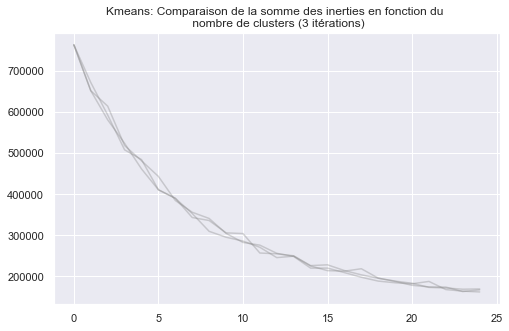

In [44]:
chaine = 'Kmeans: Comparaison de la somme des inerties en fonction du \n nombre de clusters (' + str(nb_boucles) + ' itérations)'
plt.figure(figsize=(8,5))
plt.title(chaine)
for i in range(0,nb_boucles):
    index_plot = [cluster+i*(max_clusters) for cluster in list(range(0,max_clusters))][0:max_clusters]
    sous_liste = [list(inertia.values())[index] for index in index_plot]
    sns.lineplot(list(range(0,max_clusters)),
                 sous_liste, alpha=1/nb_boucles, color='grey')

### coefficient de silhouette

In [46]:
silhouettes_kmeans = {}
max_clusters = 4
for i in range(2,max_clusters):
    sil_var = silhouette_score(
                                X = X_enc,
                                labels= list(dict_kmeans[(1,i)].labels_))
    print(sil_var)
    #print(dict_kmeans[(1,i)].labels_)
    silhouettes_kmeans[i] = sil_var

0.14897568135302236
0.162769526370079


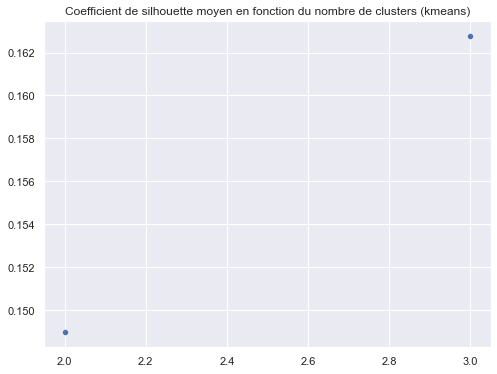

In [47]:
plt.figure(figsize=(8,6)),
plt.title('Coefficient de silhouette moyen en fonction du nombre de clusters (kmeans)')
sns.scatterplot(x = list(silhouettes_kmeans.keys()),
               y = list(silhouettes_kmeans.values()))
plt.show()

In [48]:
for key, value in silhouettes_kmeans.items():
    if value == max(silhouettes_kmeans.values()):
        print('le coefficient de silhouette est maximal pour {} clusters (score = {})'.format(key, value))
        nb_clusters = key

le coefficient de silhouette est maximal pour 3 clusters (score = 0.162769526370079)


In [49]:
nb_clusters

3

### Model

In [54]:
kmeans = KMeans(n_clusters=3, 
                verbose=1, 
                random_state=0,
               #n_jobs=-1
               ).fit(X_enc)

Initialization complete
Iteration 0, inertia 114579.32143887691.
Iteration 1, inertia 75952.15407880869.
Iteration 2, inertia 75072.17293911777.
Iteration 3, inertia 75023.84555657172.
Iteration 4, inertia 75006.389777679.
Iteration 5, inertia 74997.85192510494.
Iteration 6, inertia 74995.13325061626.
Iteration 7, inertia 74994.63899590536.
Iteration 8, inertia 74994.44414669475.
Converged at iteration 8: center shift 1.0567420671338095e-05 within tolerance 3.611539592307737e-05.


In [55]:
kmeans.labels_

array([2, 0, 1, ..., 0, 2, 0])

In [ ]:
##wcss stands for within cluster sum of squares


#wcss={}

#for k in range(2,15):
#    km = KMeans(n_clusters=k, init='k-means++', max_iter=1000 , random_state=20)
#    km = km.fit(X)
#    wcss[k] = silhouette_score(X, km.labels_)
    
##Plot graph for the wcss values and the number of clusters

#sns.pointplot(x=list(wcss.keys()), y=list(wcss.values()))
#plt.xlabel('Number of clusters K')
#plt.ylabel('Sum of square distances')
#plt.title('Elbow method for optimal K')
#plt.show()

In [ ]:
# score de silhouette
#  sklearn.metrics.silhouette_score(X, labels, *, metric='euclidean', sample_size=None, random_state=None, **kwds)[source]

# DBscan

In [57]:
dbs = DBSCAN(eps = 1, 
             min_samples=5,
               n_jobs=-1
            ).fit(X_enc.copy())

In [61]:
dbs.labels_

array([ 0, -1,  1, ..., -1, 88, -1], dtype=int64)

In [62]:
from sklearn.manifold import TSNE

X_embedded = TSNE(n_components=2, random_state=0)

NameError: name 'T' is not defined

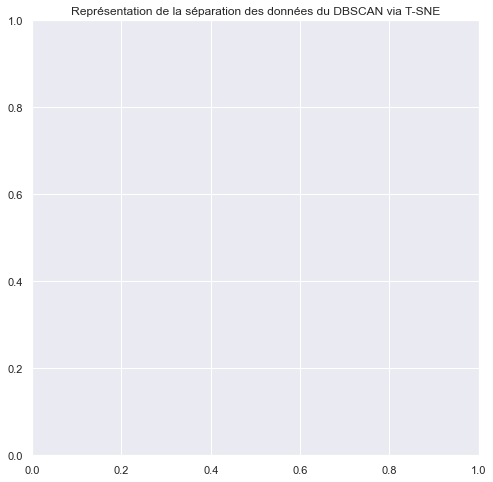

In [58]:
# Représentation via T-SNE
plt.figure(figsize=(8,8))
plt.title('Représentation de la séparation des données du DBSCAN via T-SNE')
sns.scatterplot(T[:,0], T[:,1], dbs.labels_)

### Clustering hiérarchique

In [ ]:
nb_clusters_agg = nb_clusters

In [ ]:
cah = AgglomerativeClustering(n_clusters = nb_clusters_agg
                             ).fit(X.copy())


In [47]:
graph = pd.DataFrame(data = [T[:,0], T[:,1], dict_kmeans[(1,11)].labels_]).T
graph.columns = ['X', 'Y', 'label_kmeans']

In [48]:
graph['x_pca'] = x_show
graph['y_pca'] = y_show
graph['z_pca'] = z_show

NameError: name 'x_show' is not defined

In [ ]:
graph

In [ ]:
plt.figure(figsize=(10,10))
plt.title('Représentation de la séparation des données du CAH via T-SNE')
sns.scatterplot(graph['X'], 
                graph['Y'], 
                hue = cah.labels_, 
                legend='full',
               palette=sns.color_palette("hls",nb_clusters_agg))
plt.legend(loc='upper left', labels=graph['label_kmeans'].unique())
plt.show()

In [ ]:
## ne pas utiliser PCA (permet de voir cassure) => focus TSNE (x y z)
## dbscan sur 3
# visualisation : tsne + labels/couleurs, scatterplot
# /!\ scaling / encoding données : dans la préparation des données, modelisation = modeles uniquement

In [ ]:
# ajouter features
# chercher meilleur parametrage 
# pour kmeans et pour dbscan
# /!\ responsable pédagogique